# Get the data

Here the data (tokens, embedding) comes embedding

> For this I will create a random matrix, assuming it is the embedding

In [98]:
import torch

torch.set_printoptions(
    precision=2,    
    sci_mode=False, 
    linewidth=100  
)


In [99]:
data = torch.rand(5, 10)

In [100]:
print(f'Data: {data}')

Data: tensor([[0.60, 0.91, 0.63, 0.22, 0.33, 0.26, 0.36, 0.29, 0.19, 0.39],
        [0.09, 0.54, 0.94, 0.29, 0.33, 0.99, 0.58, 0.42, 0.87, 0.69],
        [0.85, 0.60, 0.10, 0.72, 0.21, 0.03, 0.81, 0.39, 0.42, 0.86],
        [0.20, 0.80, 0.93, 0.53, 0.53, 0.44, 0.00, 0.17, 0.12, 0.42],
        [0.86, 0.11, 0.86, 0.77, 0.58, 0.76, 0.82, 0.44, 0.71, 0.44]])


# The Weight QKV matrices ($W_Q, W_K, W_V$)

Weight matrices are not just static tables of numbers; they function as filters and feature combinators that transform the raw embedding information into specific semantic intents (Questions, Answers, and Values).

1. Structure and Format (Shape)The Format: Is defined as $(d_{model}, d_{qkv})$.The Axis of Lines ($d_{model}$): Represents each of the dimensions of the original input embedding (e.g., the 512 features that define the token).The Column Axis ($d_{qkv}$): Represents the number of projected features (e.g., 100 weight dimensions). Each column functions as a unique linear combination (a projection "recipe").

2. The Concept of Column as "Join" (Feature Recipe)If we go from 512 dimensions to 100 columns of weights, it means we are combining the 512 input features in 100 totally different ways.Practical Example: * Column 1 of $W_Q$ can mix the weights to focus on "grammatical gender", creating a specific question about it. Column 2 next to it can mix the weights to focus on "degree of formality", generating another completely different question criterion.

3. The Mathematical Operation (Token Projection)The transformation occurs through the dot product (dot product) between the vector of each token and each column of the weight matrix.Scalar Transformation: When a token (row) interacts with a column of weights, all its 512 features are multiplied by their respective weights and added together, resulting in a single scalar value.Independence: This operation is applied individually and in parallel for each token in the sequence.

4. The Final Result: The Projected MatrixAt the end of the multiplications, the resulting matrices ($Q, K, V$) have the format $(\text{tokens}, d_{qkv})$.In this new framework, the original features have been fully distilled: each row still represents the same token, but now each column represents a question, answer, or abstract, mapped value, ready for calculating attention scores.

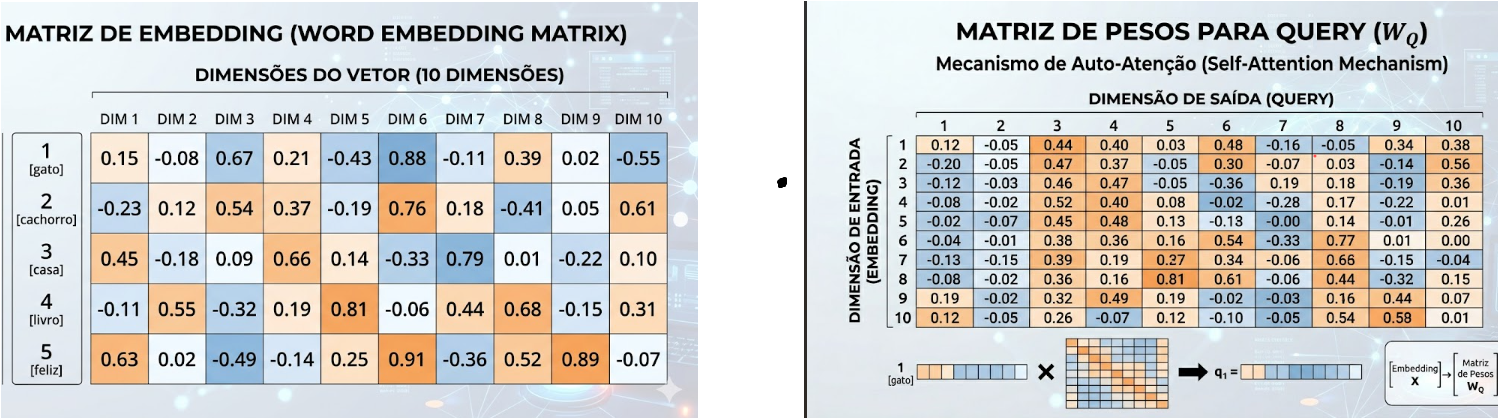

In [101]:
Wq = torch.rand(10, 10)
Wk = torch.rand(10, 10)
Wv = torch.rand(10, 10)


print(f'Q Weights Matrix: {Wq}\n')
print(f'K Weights Matrix: {Wk}\n')
print(f'V Weights Matrix: {Wv}\n')

Q Weights Matrix: tensor([[0.57, 0.98, 0.48, 0.85, 0.82, 0.64, 0.12, 0.69, 0.40, 0.10],
        [0.04, 0.51, 0.49, 0.78, 0.33, 0.53, 0.20, 0.06, 0.08, 0.01],
        [0.40, 0.35, 0.81, 0.17, 0.17, 0.18, 0.79, 0.14, 0.09, 0.01],
        [0.40, 0.50, 0.28, 0.73, 0.60, 0.83, 0.68, 0.80, 0.33, 0.41],
        [0.66, 0.14, 0.25, 0.59, 0.21, 0.88, 0.19, 0.44, 0.32, 0.26],
        [0.65, 0.11, 0.42, 0.18, 0.03, 0.85, 0.76, 0.65, 0.81, 0.40],
        [0.49, 0.75, 0.94, 0.03, 0.33, 0.48, 0.06, 0.87, 0.87, 0.99],
        [0.53, 0.53, 0.12, 0.47, 0.79, 0.68, 0.93, 0.85, 0.26, 0.12],
        [0.82, 0.94, 0.52, 0.70, 0.38, 0.34, 0.14, 0.50, 0.96, 0.66],
        [0.03, 0.70, 0.43, 0.26, 0.27, 0.09, 0.91, 0.37, 0.35, 0.23]])

K Weights Matrix: tensor([[0.75, 0.78, 0.45, 0.28, 0.24, 0.79, 0.65, 0.42, 0.56, 0.42],
        [0.71, 0.67, 0.65, 0.02, 0.95, 0.19, 0.15, 0.24, 0.42, 0.80],
        [0.48, 0.95, 0.43, 0.57, 0.31, 0.02, 0.35, 0.12, 0.89, 0.43],
        [0.33, 0.24, 0.70, 0.74, 0.08, 0.69, 0.86, 0

## QKV


After multiplying the original embeddings by their respective weight matrices ($W_Q, W_K, W_V$), we obtain the three fundamental matrices of the attention mechanism. The format (shape) of all of them is $(\text{tokens}, d_{qkv})$.

Below is the exact conceptual meaning of each row and column within these structures:

1. Query Array ($Q$) — The QuestionsEach Line: Represents a sequence-specific token focused on fetching information (e.g., the "cat" token trying to understand its relationship to the rest of the sentence).Each Column: Represents an abstract semantic or syntactic question learned by the model (e.g., "Who performed the action?", "Is this token a verb?", "Is there a close adjective?").

2. Keys Matrix ($K$) — The Answers (Keys)Each Row: Represents a specific token offering its context information to the others.Each Column: Represents the answer or matching profile for the questions in the $Q$ matrix. How it works: If column 3 of $Q$ asks the question "Where did the event occur?", column 3 of $K$ will contain the values that indicate how well each token in the sentence fits as a valid answer to that geographic question.

3. Values Matrix ($V$) — The Values (The Content)Each Line: Represents the actual and distilled semantic information of each token.

Each Column: Represents a dimension of rich token features that will be extracted and mixed in the final step. Crucial Difference: While $Q$ and $K$ serve only as a "search system" to calculate who should look at whom (generating the Scores), the $V$ matrix holds the actual content that will be inherited by the tokens after we discover the importance of each one.

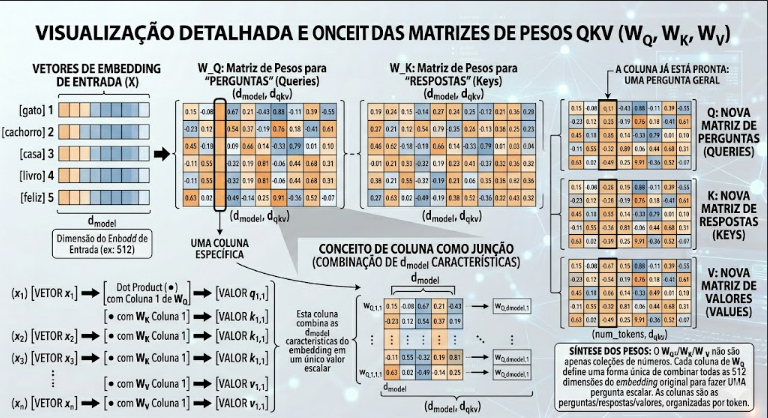


In [102]:
Q = data @ Wq
K = data @ Wk
V = data @ Wv

print(f'Q Matrix: {Q}\n')
print(f'K Matrix: {K}\n')
print(f'V Matrix: {V}\n')


Q Matrix: tensor([[1.60, 2.33, 2.13, 2.12, 1.63, 2.14, 1.83, 1.85, 1.48, 0.96],
        [2.66, 2.96, 2.99, 2.25, 1.72, 2.81, 3.05, 2.81, 2.86, 1.98],
        [1.96, 3.37, 2.44, 2.60, 2.35, 2.57, 2.11, 2.89, 2.25, 1.77],
        [1.57, 1.82, 1.97, 2.01, 1.32, 2.20, 2.28, 1.63, 1.25, 0.78],
        [3.25, 3.58, 3.22, 2.84, 2.49, 3.52, 2.97, 3.69, 3.16, 2.30]])

K Matrix: tensor([[2.65, 2.81, 1.95, 1.62, 1.95, 2.01, 2.10, 1.70, 2.50, 2.40],
        [3.64, 3.64, 2.83, 2.67, 2.62, 2.80, 2.98, 2.37, 3.44, 3.45],
        [3.24, 2.71, 2.31, 2.21, 1.75, 2.99, 3.17, 2.44, 2.74, 2.76],
        [2.34, 3.02, 2.08, 1.86, 1.94, 1.85, 2.00, 1.46, 2.86, 2.45],
        [3.95, 3.72, 2.87, 3.15, 2.20, 3.65, 3.97, 2.68, 3.87, 3.44]])

V Matrix: tensor([[1.97, 2.41, 1.87, 1.84, 3.18, 2.44, 1.76, 1.52, 2.50, 1.94],
        [3.21, 3.33, 3.14, 2.56, 3.66, 4.04, 2.21, 1.79, 2.60, 2.68],
        [2.31, 2.44, 2.19, 2.08, 3.48, 2.59, 1.67, 1.71, 2.90, 2.31],
        [2.10, 2.57, 1.98, 1.89, 3.11, 2.99, 1.80, 1.51,

# Scores


1. Remembering that QKV matrices represent (tokens, qkv)
The Attention Mechanism works by asking and answering, so we will dot product between Q (questions) and K (answers), resulting in a temporary attention matrix that we will apply softmax

- This new matrix represents the Q of each token multiplied by the K of each token, generating an attention matrix, where each token asks its questions (columns of Q) to all other tokens and is answered by the answers (columns of K transposed)
- And so resulting in this attention matrix with shape (tokens, tokens) where the rows are each token (Q), and each column each token as well (K), and the scalar numbers of each part is how much each question is answered by the answer

2. The Scale Factor (The Division by $\sqrt{d_k}$)Before applying Softmax, the raw scores need to be divided by $\sqrt{d_k}$ (where $d_k$ is the number of columns/dimensions of Q and K).What it's for: As $d_k$ grows, the dot product generates very high raw numbers. This division controls the variance, preventing the largest number from exploding and saturating Softmax.

> We need to transpose the matrix K, since as its original shape is (tokens, K) and Q represents (tokens, Q) since (Tokens, Q) @ (Tokens, K) -> Q != Tokens

In [103]:

d_k = torch.tensor(K.shape[1], dtype=torch.float32)

scores = (Q @ K.T) / torch.sqrt(d_k)

print(f'Score Matrix:\n{scores}')

# Here I'm not gonna use the softmax function, here, cuz have the tril after

Score Matrix:
tensor([[12.29, 17.24, 14.99, 12.41, 19.12],
        [18.00, 25.20, 22.06, 18.13, 28.07],
        [16.62, 23.25, 20.05, 16.82, 25.58],
        [11.34, 15.96, 14.11, 11.39, 17.95],
        [21.32, 29.83, 26.02, 21.43, 33.06]])


# Tril (Or not)

In the original attention matrix of format $(\text{tokens}, \text{tokens})$, each word has the ability to look at the entire text, both past and future. While this is perfect for the Encoder (which processes existing text), it becomes a serious error in the Decoder (focused on text generation).

1. The "Leak of the Future" Problem (Data Leakage) Causal Prediction: Autoregressive models (such as GPT) generate text word for word. To predict the next word, the model must rely only on the context that has already been generated (the past). 
- The Line 1 Paradox: Without a constraint, the first word of the sentence ($x_1$) would dot the product with the keys ($K$) of tokens that appear much later in the sequence ($x_{50}$, for example).
- The Impact: This would allow the model to "cheat" during training, looking at the future response before predicting it. When it comes to using the model in practice (inference), the future does not exist, which would cause a total drop in performance.

2. The Mathematical Solution: Lower Triangular Matrix (tril)
- To ensure that each token only looks at itself and the previous ones, we apply a mask to the scores array (before Softmax). Operation tril (Lower Triangular): 
- We keep the values of the main diagonal and those below it intact. The "Suffocation" of the Future: All values that are above the main diagonal (representing connections to future tokens) are replaced by $-\infty$ (minus infinity).
- The Effect on Softmax: Since $e^{-\infty} = 0$, when the Softmax function is applied to each row, the probability of attention for any future word becomes exactly 0%.

3. The Practical Result per LineLine 1 (Token 1): Can only pay attention to yourself (100% focused attention).Line 2 (Token 2): Can distribute your attention between Token 1 and Token 2.Line $N$ (Token $N$): Can look back and evaluate all history up to the current moment.


In [104]:
import torch.nn.functional as F


scores_trilled = torch.tril(scores)
scores_trilled_softmax = F.softmax(scores_trilled, dim = 1)

print(f'Score Matrix trilled with softmax:\n{scores_trilled_softmax}')


# Here how are a low dimensional matrix, will occurs the

Score Matrix trilled with softmax:
tensor([[1.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 1.00, 0.00, 0.00, 0.00],
        [0.00, 0.96, 0.04, 0.00, 0.00],
        [0.01, 0.85, 0.13, 0.01, 0.00],
        [0.00, 0.04, 0.00, 0.00, 0.96]])


# New valeus (attention output)

Now that we have the Attention Matrix normalized by Softmax with the format $(\text{tokens}, \text{tokens})$, we will use these weights to update and contextualize our Values matrix ($V$).The goal of this step is to make the vectors of each word stop being isolated representations and start carrying the meaning of the words around them.

1. The Mathematical Operation ($Aten\c{c}\tilde{a}o \times V$)Format Alignment (Shapes): We multiply the Attention Matrix by the Value matrix ($V$):$$(\text{tokens}, \text{tokens}) \times (\text{tokens}, d_{v}) \rightarrow (\text{tokens}, d_{v}) $$The Result: We generate a new matrix, commonly called $Z$, that exactly preserves the original shape of the tokens and their value dimensions ($d_v$).

2. What really happens? (The "Weighted Average")Instead of thinking only about multiplication of isolated matrices, what occurs at the heart of the Transformer is a linear combination based on relevance:Line by Line: We look at the line of Token 1 in the Attention Matrix. It gives us percentages (ex: $10\%$ for Token 1, $90\%$ for Token 2, $0\%$ for the rest).Feature Distillation: The model goes to the $V$ matrix, takes $10\%$ of the features from the Token 1 vector, sums it with $90\%$ of the features from the Token 2 vector, and ignores the others. The Contextualized Vector: The result of this sum is the new Token 1 vector in the $Z$ matrix.

3. The Practical Meaning of $Z$Each row of the new $Z$ matrix still represents the same token as the input, but now with a fundamental difference: its numerical values have been updated. If the word "bank" in row 3 paid too much attention to the word "money" in row 1, the new vector $z_3$ will have its columns modified to absorb the financial context. $Z$ columns become dynamic and rich representations, ready to be sent to the next layers of the network (such as Feed-Forward).


> All tokens have their QKV and their new updated values

In [105]:
new_values = scores_trilled_softmax @ V

print(f'Old values:\n{V}\n')
print(f'Values after the attention score:\n{new_values}\n')

Old values:
tensor([[1.97, 2.41, 1.87, 1.84, 3.18, 2.44, 1.76, 1.52, 2.50, 1.94],
        [3.21, 3.33, 3.14, 2.56, 3.66, 4.04, 2.21, 1.79, 2.60, 2.68],
        [2.31, 2.44, 2.19, 2.08, 3.48, 2.59, 1.67, 1.71, 2.90, 2.31],
        [2.10, 2.57, 1.98, 1.89, 3.11, 2.99, 1.80, 1.51, 2.11, 2.08],
        [3.20, 2.95, 3.60, 3.10, 4.43, 3.76, 2.73, 1.52, 3.16, 3.05]])

Values after the attention score:
tensor([[1.97, 2.41, 1.87, 1.84, 3.18, 2.44, 1.76, 1.52, 2.50, 1.94],
        [3.21, 3.33, 3.14, 2.55, 3.66, 4.03, 2.21, 1.79, 2.60, 2.68],
        [3.18, 3.29, 3.10, 2.54, 3.65, 3.98, 2.19, 1.79, 2.61, 2.67],
        [3.07, 3.20, 2.99, 2.48, 3.63, 3.82, 2.13, 1.78, 2.63, 2.62],
        [3.20, 2.96, 3.58, 3.07, 4.40, 3.77, 2.71, 1.53, 3.14, 3.03]])



# Add & Norm 

These are **two separate operations** applied in sequence after attention (and after FFN):

## 1. ADD — Residual Connection

### Why does it exist?

| Problem | Solution |
|---|---|
| Gradient disappears in deep networks | Creates a direct "shortcut" for the gradient to flow |
| Layers need to learn complex transformations | The layer only learns the **correction**, not the complete transformation |
| Multi-layer stacking degrades performance | Each layer just needs to adjust what already exists |

> The idea comes from **ResNets** (2015) — instead of learning 'F(x)', the network learns 'F(x) + x'.

---

## 2. NORM — Layer Normalization

Normalizes values to have **mean ≈ 0** and **standard deviation ≈ 1**, per token.

### Why does it exist?

| Problem | Solution |
|---|---|
| Activations explode or die along layers | Keeps distribution stable |
| Unstable training with higher learning rates | Allows for higher LRs → faster training |
| BatchNorm does not work well with variable sequences | LayerNorm operates by sample, regardless of batch |


> **Without Add & Norm**, a Transformer with 12+ layers would be virtually impossible to train stably.
> the 1st add are the embeddings, is the 2 add the output of the 1 Add & Norm

In [106]:
x = data + new_values

print(f'X after the attention and first add:\n{x}')

X after the attention and first add:
tensor([[2.57, 3.32, 2.50, 2.06, 3.51, 2.70, 2.12, 1.81, 2.70, 2.32],
        [3.31, 3.87, 4.08, 2.85, 4.00, 5.02, 2.79, 2.21, 3.47, 3.38],
        [4.03, 3.89, 3.20, 3.26, 3.87, 4.01, 2.99, 2.18, 3.03, 3.53],
        [3.27, 4.00, 3.92, 3.01, 4.16, 4.26, 2.13, 1.95, 2.76, 3.04],
        [4.06, 3.07, 4.44, 3.84, 4.98, 4.53, 3.53, 1.97, 3.85, 3.47]])


In [107]:
μ = torch.mean(x, dim=-1, keepdim=True)
σ = torch.std(x, dim=-1, keepdim=True)
x = (x - μ) / (σ +  1e-5)
print(f'X after the attention and first NORM:\n{x}')


X after the attention and first NORM:
tensor([[ 0.02,  1.41, -0.11, -0.94,  1.77,  0.26, -0.82, -1.40,  0.26, -0.45],
        [-0.24,  0.47,  0.73, -0.82,  0.63,  1.92, -0.89, -1.62, -0.04, -0.15],
        [ 1.07,  0.84, -0.34, -0.24,  0.80,  1.04, -0.69, -2.08, -0.63,  0.22],
        [ 0.03,  0.90,  0.81, -0.29,  1.10,  1.23, -1.35, -1.57, -0.60, -0.26],
        [ 0.34, -0.84,  0.79,  0.08,  1.42,  0.89, -0.28, -2.13,  0.09, -0.36]])


# Feed Forward

In [108]:
W1 = torch.rand(10, 20) # Normally we use 4 times the input, so here will become 40 instead 20
W2 = torch.rand(20, 10)
bias1 = torch.rand(20)
bias2 = torch.rand(10)

ffn1 = x @ W1 + bias1
ffn1 = torch.relu(ffn1)
print(f'The matrix after the first layer:\n{x}\n')

ffn2 = ffn1 @ W2 + bias2
print(f'The matrix after the second layer:\n{x}\n')



The matrix after the first layer:
tensor([[ 0.02,  1.41, -0.11, -0.94,  1.77,  0.26, -0.82, -1.40,  0.26, -0.45],
        [-0.24,  0.47,  0.73, -0.82,  0.63,  1.92, -0.89, -1.62, -0.04, -0.15],
        [ 1.07,  0.84, -0.34, -0.24,  0.80,  1.04, -0.69, -2.08, -0.63,  0.22],
        [ 0.03,  0.90,  0.81, -0.29,  1.10,  1.23, -1.35, -1.57, -0.60, -0.26],
        [ 0.34, -0.84,  0.79,  0.08,  1.42,  0.89, -0.28, -2.13,  0.09, -0.36]])

The matrix after the second layer:
tensor([[ 0.02,  1.41, -0.11, -0.94,  1.77,  0.26, -0.82, -1.40,  0.26, -0.45],
        [-0.24,  0.47,  0.73, -0.82,  0.63,  1.92, -0.89, -1.62, -0.04, -0.15],
        [ 1.07,  0.84, -0.34, -0.24,  0.80,  1.04, -0.69, -2.08, -0.63,  0.22],
        [ 0.03,  0.90,  0.81, -0.29,  1.10,  1.23, -1.35, -1.57, -0.60, -0.26],
        [ 0.34, -0.84,  0.79,  0.08,  1.42,  0.89, -0.28, -2.13,  0.09, -0.36]])



# Add & Norm (2)

In [109]:
x = ffn2 + x
μ = torch.mean(x, dim=-1, keepdim=True)
σ = torch.std(x, dim=-1, keepdim=True)
x = (x - μ) / (σ +  1e-5)
               
print(f'X after the attention and first add:\n{x}')

X after the attention and first add:
tensor([[ 0.88,  0.73, -0.63, -0.18,  0.71,  0.13, -0.05,  0.89, -0.03, -2.44],
        [ 1.89, -0.32, -0.00,  0.07, -0.09,  1.34, -0.43, -0.51, -0.20, -1.74],
        [ 1.97,  0.54, -0.87,  0.29, -0.10,  0.55, -0.31,  0.32, -0.62, -1.76],
        [ 1.49, -0.07,  0.07,  0.53,  0.25,  0.62, -0.43,  0.48, -0.67, -2.27],
        [ 2.12, -0.13, -0.61,  0.07,  0.83,  0.42, -0.52, -0.63,  0.06, -1.60]])


# Blocks (or layers)

Each complete sequence it encompasses from data entry, passes through the self-attention mechanism, dense neural networks, and residual connections and normalization mechanisms, forms a Transformer Block (often called a Layer or Layer).A modern language model has not just one, but dozens of blocks stacked in series (GPT-3, for example, has 96 blocks).

1. The Data Flow within a BlockA standard block (especially in the case of a Decoder) is composed strictly of the following anatomy:Multi-Head Attention (with Causal Mask): Where QKV projections occur, Scores are calculated with a scale factor, the tril mask is applied and the context vector ($Z$) is generated.First Add & Norm (Residual Connection): Where we add the original embedding to the $Z$ output (to prevent gradients from disappearing) and normalize the values to maintain numerical stability. Feed-Forward Network (FFN): A classical layer-by-layer linear neural network that processes each token independently to extract high-level patterns. Second Add & Norm: A final layer of residual summation and normalization that delivers the refined tokens to the next step.

2. Why stack multiple blocks? (The Concept of Hierarchy)The output of a block (the resulting array with format $\text{tokens}, d_{model}$) serves exactly as the input (the "new embedding") to the next block. This stacking is what gives the "intelligence" power to the model due to hierarchical processing: Initial Blocks (Low Layers): Learn superficial, syntactic and immediate relationships between words (e.g. verb agreement, punctuation, articles and close nouns).Intermediate Blocks: Begin to capture the complex grammatical structure and far-reaching dependencies in the sentence. End Blocks (High Layers): Absorb the purely abstract meaning, global context, text theme, ironies, intentions, and deep semantics necessary to decide, with high precision, what the next generated word will be.

By the end of the last block, the last context vector will be fully mature and ready to be delivered to the LM Head layer to be projected against the vocabulary.

# Summarizes

1. vocab_size (Vocabulary Size): What it is: The total number of unique tokens that your tokenizer can recognize and transform into numbers. Function: It directly defines the size of two giant matrices in your model: the first Embedding matrix (which converts IDs to vectors) and the final LM Head matrix (which projects the vectors back to word probabilities). If your vocabulary is 30,000 words, your vocab_size will be 30,000.

2. d_model(Model Dimension / Embedding Dimension):What is it: It is the size (number of columns) of the embedding vector that represents each token in the model input.Function: Sets the base width of the Transformer. All residual blocks maintain this dimension to allow summation connections (Add & Norm). A larger d_model allows the model to store much richer and more detailed information about each word. Classic example: 512 (Original transformer), 4096 (Llama 3 8B).

3. seq_len(Context Length/Sequence Size):What is it: The maximum number of tokens (words/subwords) that the model can process at once in a context window.Function: Sets the maximum size of the input text. It directly affects the attention matrix $(\text{tokens}, \text{tokens})$, causing the memory cost to grow quadratically ($\text{seq\_len}^2$). The higher the seq_len, the more past facts the model can remember when generating a text.heads (Number of Attention Heads / Multi-Head Attention):What is it: The number of parallel attention paths that the model has within a single block.Function: Instead of calculating attention once, the model divides the search space into multiple "heads". This allows the model to focus on different things at the same time. For example: Head 1 focuses on finding the subject of the sentence, Head 2 focuses on verbs and Head 3 looks for rhymes.

4. d_qkv (Dimension of QKV Projections):What is it: The size of the Query, Key and Value vectors after multiplication by the weight matrices.Function: Generally, this value is calculated automatically by dividing the global dimension by the heads ($d_{qkv} = d_{model} / \text{heads}$). This ensures that even dividing the model into multiple heads to look at different contexts, the total computational cost remains balanced and equivalent to processing a single giant head.

5. d_ffn (Feed-Forward Layer Dimension):What is it: The number of neurons in the hidden middle layer of the linear neural network present in each block.Function: After the attention mechanism extracts the context, the tokens pass through a dense network (Feed-Forward). This layer often expands the dimension to a value much larger than the d_model (usually $4\times$ larger) to give the model room to perform complex nonlinear computations, and then squeezes it back to the size of the d_model.

6. blocks (Number of Layers / Layers):What is it: The number of complete blocks (Attention + FFN + Add&Norm) stacked in series in the model.Function: Sets the depth of the Transformer. The more blocks the model has, the more capacity it has to process abstract reasoning, complex logic, feelings, and deep contexts, as information is refined layer by layer before generating the final word.